In [1]:
import xarray as xr
import numpy as np
import os, sys

In [2]:
os.listdir('/gws/nopw/j04')

['wcssp_india',
 'vision',
 'odanceo',
 'acacia',
 'quasar',
 'tids',
 'scenario',
 'mohc_shared',
 'parachute',
 'ramip']

In [3]:
ROOT_DIR = '/gws/ssde/j25a/extant/data'

In [4]:
potential_models = np.array(os.listdir(ROOT_DIR))
models = np.array([m for m in potential_models if os.path.isdir(os.path.join(ROOT_DIR, m))])
models

array(['ACCESS-CM2', 'ACCESS-ESM1-5', 'BCC-CSM2-MR', 'BCC-ESM1', 'CESM2',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM2', 'CanESM5',
       'E3SM-1-0', 'EC-Earth3-Veg', 'EC-Earth3', 'ERA5', 'FGOALS-g3',
       'GISS-E2-1-G', 'HadGEM3-GC31-CANARI', 'HadGEM3-GC31-LL',
       'HadGEM3-GC31-MM', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L',
       'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3',
       'NorESM2-LM', 'RCM', 'UKESM1-0-LL', 'downloading'], dtype='<U19')

In [5]:
LESMIP_MODELS = ['ACCESS-ESM1-5',
       'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5',
       'GISS-E2-1-G', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR',
       'MIROC6', 'MPI-ESM1-2-LR',
       'NorESM2-LM']

In [6]:
len(LESMIP_MODELS)

10

In [7]:
from glob import glob

In [8]:
from collections import defaultdict
from pprint import pprint

In [9]:
# nested = lambda: defaultdict(nested)
# model_list_dict = nested()
# model_list_dict

In [10]:
model_list_dict = defaultdict(dict)


for model in LESMIP_MODELS:
    print(model)
    model_path = os.path.join(ROOT_DIR, model, 'day')
    variables = os.listdir(model_path)
    for variable in variables:
        # print(variable)
        variable_path = os.path.join(model_path, variable)
        if os.path.isdir(variable_path): 
            glob_path = os.path.join(variable_path, '**', '*.nc')
            print(f'searching {glob_path}')
            full_paths = glob(glob_path, recursive=True)
            fnames = full_paths#list(map(os.path.basename, full_paths))
            fnames_grouped = defaultdict(list)
            for fname in fnames:
                fnames_grouped[fname.split('_')[3]].append(fname)

            model_list_dict[model][variable] = {'path': variable_path, 'fnames': fnames_grouped}

ACCESS-ESM1-5
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/va/**/*.nc
searching /gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/vas/**/*.nc
CMCC-CM2-SR5
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/pr/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/va/**/*.nc
CNRM-CM6-1
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/psl/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tas/**/*.nc
searching /gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax/**/*.nc
searching /gws/ssde/j25a/extant/

In [11]:
model_list_dict

defaultdict(dict,
            {'ACCESS-ESM1-5': {'pr': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/pr',
               'fnames': defaultdict(list, {})},
              'psl': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/psl',
               'fnames': defaultdict(list, {})},
              'tas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tas',
               'fnames': defaultdict(list, {})},
              'tasmax': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
               'fnames': defaultdict(list, {})},
              'uas': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas',
               'fnames': defaultdict(list,
                           {'historical': ['/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_19500101-19991231.nc',
                             '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/uas/uas_day_ACCESS-ESM1-5_historical_r10i1p1f1_gn_20000101-20141231.nc',
  

In [12]:
{model: values.get('tasmax') for model, values in model_list_dict.items()}

{'ACCESS-ESM1-5': {'path': '/gws/ssde/j25a/extant/data/ACCESS-ESM1-5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CMCC-CM2-SR5': {'path': '/gws/ssde/j25a/extant/data/CMCC-CM2-SR5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CNRM-CM6-1': {'path': '/gws/ssde/j25a/extant/data/CNRM-CM6-1/day/tasmax',
  'fnames': defaultdict(list, {})},
 'CanESM5': {'path': '/gws/ssde/j25a/extant/data/CanESM5/day/tasmax',
  'fnames': defaultdict(list, {})},
 'GISS-E2-1-G': {'path': '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax',
  'fnames': defaultdict(list,
              {'hist-sol': ['/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_18500101-18991231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19000101-19391231.nc',
                '/gws/ssde/j25a/extant/data/GISS-E2-1-G/day/tasmax/tasmax_day_GISS-E2-1-G_hist-sol_r6i1p1f2_gn_19400101-19791231.nc',
                '/gws/ssde

In [13]:
model = 'HadGEM3-GC31-LL'

In [14]:
sample_dict = model_list_dict[model]['tasmax']

In [15]:
sample_dict.keys()

dict_keys(['path', 'fnames'])

In [16]:
sample_dict['fnames'].keys()

dict_keys(['hist-GHG', 'hist-aer', 'hist-lu', 'hist-nat', 'hist-sol', 'hist-totalO3', 'hist-volc', 'historical', 'day'])

In [17]:
hist_path = sample_dict['fnames']['historical'][0]
hist_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc'

In [18]:
hist_path_split = os.path.basename(hist_path).split('.')[0].split('_')
experiment, ensemble_member, _, time = hist_path_split[-4:]
experiment, ensemble_member, _, time

('historical', 'r11i1p1f3', 'gn', '18500101-19491230')

In [19]:
hist_match = [f for f in sample_dict['fnames']['historical'] if ((experiment in f) and (ensemble_member in f))]
hist_match

['/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_18500101-19491230.nc',
 '/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_19500101-20141230.nc']

In [20]:
import re

In [21]:
hist_wild_path = re.sub(r'_gn_\d+-\d+\.nc$', '_gn_*.nc', hist_match[0])
hist_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/historical/tasmax_day_HadGEM3-GC31-LL_historical_r11i1p1f3_gn_*.nc'

In [22]:
# hist_da = xr.open_mfdataset(hist_wild_path)

In [23]:
ensmemble_date_str = "_".join(hist_path.split('.')[0].split('_')[-3:])
ensmemble_date_str

'r11i1p1f3_gn_18500101-19491230'

In [24]:
hist_nat_path = sample_dict['fnames']['hist-nat'][0]
hist_nat_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_18500101-19491230.nc'

In [25]:
hist_nat_wild_path = re.sub(r'_gn_\d+-\d+.nc$', '_gn_*.nc',hist_nat_path)
hist_nat_wild_path

'/gws/ssde/j25a/extant/data/HadGEM3-GC31-LL/day/tasmax/hist-nat/tasmax_day_HadGEM3-GC31-LL_hist-nat_r10i1p1f3_gn_*.nc'

In [33]:
# hist_nat_da = xr.open_mfdataset(hist_nat_path)
# hist_nat_da.tasmax

In [34]:
# hist_da.tasmax.encoding['chunksizes']

In [31]:
#hist_da = xr.open_dataset(hist_path)

In [26]:
import matplotlib.pyplot as plt

In [27]:
loc = dict(lat=-62, lon=57, method='nearest')

In [193]:
arr = hist_da.tasmax.sel(**loc).values

In [194]:
arr_nat = hist_nat_da.tasmax.sel(**loc).values

In [195]:
hist_nat_time = hist_nat_da.time.values
hist_time = hist_da.time.values

In [196]:
hist_nat_da

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 36000, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 288kB 1850-01-01 12:00:00 ... 1949-12-30 12:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 576kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    tasmax     (time, lat, lon) float32 4GB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            DAMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  154800.0
    creation_date:          2021-12-21T14:13:06Z
    ...                     ...
    tracking_id:            hdl:21.14100/3e826075-70b4-4f00-a72f-e79b63e042a0
    variable_id:            tasmax
    variable_name:          tasmax
    variant_label:          r10i1p1f3
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.6.1

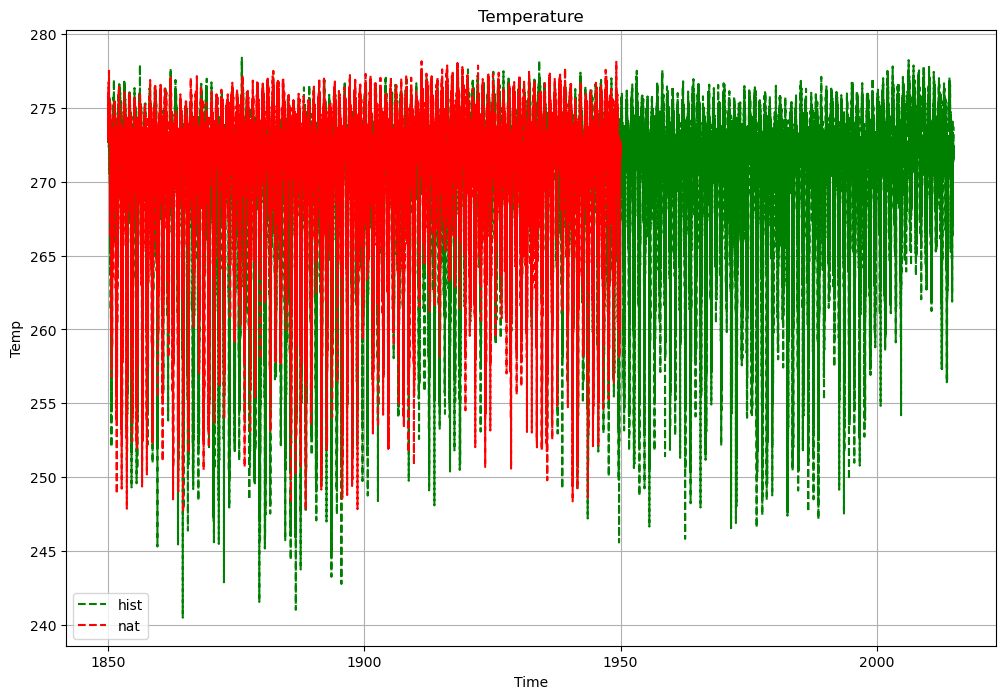

In [197]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
ax.plot(hist_time, arr, linestyle='--', color='green', label='hist')
ax.plot(hist_nat_time, arr_nat, linestyle='--', color='red', label='nat')

ax.set_ylabel('Temp')
ax.set_xlabel('Time')
ax.grid()
ax.set_title('Temperature')
ax.legend()


# Percentiles- dask + xarry

In [28]:

import dask
from dask.distributed import LocalCluster, Client

client = Client(LocalCluster(n_workers=4, threads_per_worker=2, memory_limit="8GB"))

2026-07-23 18:03:38,229 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1909d5267adcb06ea5bd09b1dc26d4fc initialized by task ('rechunk-merge-rechunk-transfer-84f769cd40ed2ebf591afc55a3ebeed8', 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:38257
2026-07-23 18:03:43,591 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1909d5267adcb06ea5bd09b1dc26d4fc deactivated due to stimulus 'task-finished-1784829823.5900383'
2026-07-23 18:07:28,275 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1909d5267adcb06ea5bd09b1dc26d4fc initialized by task ('rechunk-merge-rechunk-transfer-84f769cd40ed2ebf591afc55a3ebeed8', 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:41921
2026-07-23 18:07:33,820 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1909d5267adcb06ea5bd09b1dc26d4fc deactivated due to stimulus 'task-finished-1784830053.8186975'
2026-07-23 18:10:47,985 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1909d5267adcb06ea5bd09b1dc26

In [29]:
hist_ds = xr.open_mfdataset(
    hist_wild_path,
    chunks={'time': 3650, 'lat': -1, 'lon': -1},
    parallel=True,
).sel(lat=slice(-90, -60))

In [30]:
hist_nat_ds = xr.open_mfdataset(
    hist_nat_path,
    chunks={'time': 3650, 'lat': -1, 'lon': -1},
    parallel=True,
).sel(lat=slice(-90, -60)).chunk({'time': -1, 'lat': -1, 'lon': -1})

In [31]:
nat_sorted = xr.apply_ufunc(
    np.sort, hist_nat_ds.tasmax,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    dask='parallelized',
    output_dtypes=[np.float32],
)

In [32]:
q = 99

In [36]:
nat_q = xr.apply_ufunc(
    sorted_percentile, nat_sorted, q,
    input_core_dims=[['time'], []],
    dask='parallelized',
    vectorize=True,
    output_dtypes=[np.float32],
).persist()

In [59]:
window = 30# * 365

In [60]:
from dask.distributed import wait

In [77]:
exceed = (hist_ds.tasmax > nat_q).persist()
counts_annual = exceed.resample(time='YE').sum().persist()
counts = counts_annual.rolling(time=window).sum().persist()
wait(counts);

p_hist = counts / (window *365)
p_nat = (100 - q) / 100
pr = (p_hist / p_nat)

In [79]:
# p_hist = counts / window
# p_nat = (100 - q) / 100
# pr = (p_hist / p_nat)

In [80]:
pr = pr.compute()

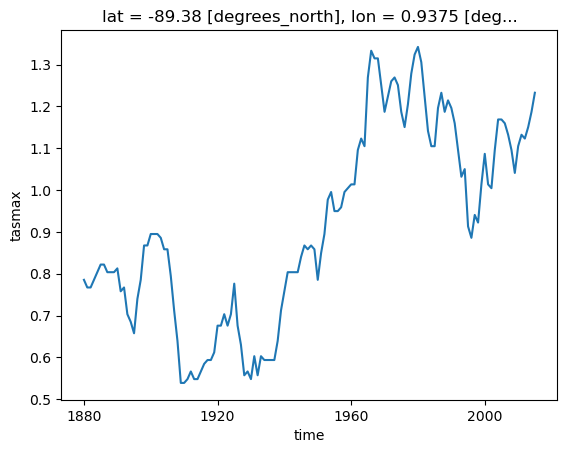

In [81]:
pr.isel(lat=0, lon=0).plot()

In [82]:
qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Text(0.5, 1.0, 'Spatial spread of PR across Antarctic gridpoints, 99th percentile TXx')

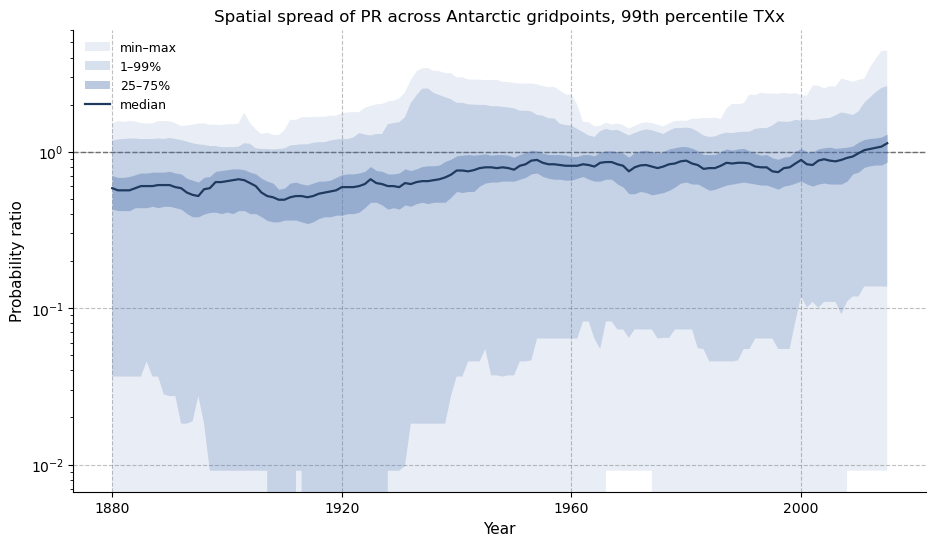

In [83]:
import matplotlib.pyplot as plt
import numpy as np

qs = pr.quantile([0.0, 0.01, 0.25, 0.5, 0.75, 0.99, 1.0], dim=['lat', 'lon'])

fig, ax = plt.subplots(figsize=(11, 6))
ax.axhline(1.0, color='0.4', lw=1.0, ls='--', zorder=1)

ax.fill_between(pr.time.values, qs.sel(quantile=0.0), qs.sel(quantile=1.0),
                color='#4C72B0', alpha=0.12, lw=0, label='min–max', zorder=2)
ax.fill_between(pr.time.values, qs.sel(quantile=0.01), qs.sel(quantile=0.99),
                color='#4C72B0', alpha=0.22, lw=0, label='1–99%', zorder=3)
ax.fill_between(pr.time.values, qs.sel(quantile=0.25), qs.sel(quantile=0.75),
                color='#4C72B0', alpha=0.38, lw=0, label='25–75%', zorder=4)
ax.plot(pr.time, qs.sel(quantile=0.5), lw=1.6, color='#1F3A5F',
        label='median', zorder=5)

ax.set_yscale('log')
ax.set_ylabel('Probability ratio', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, color='grey')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_title(f'Spatial spread of PR across Antarctic gridpoints, {q}th percentile TXx',
             fontsize=12)

Text(0.5, 1.0, 'PR, 99th percentile TXx — final 0-yr window')

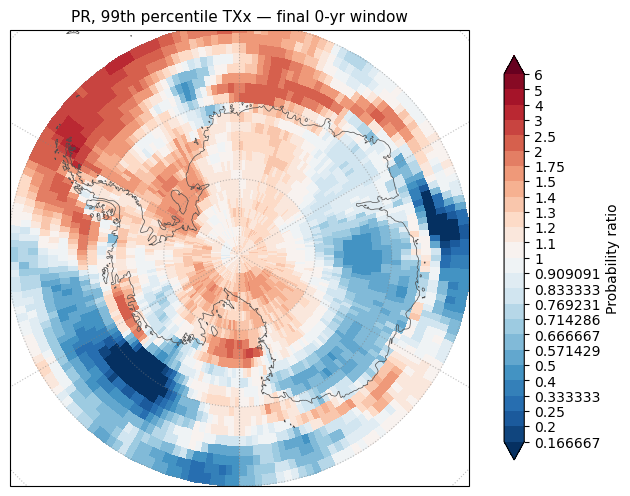

In [91]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

pr_final = pr.isel(time=-1)

fig = plt.figure(figsize=(7.5, 7))
ax = fig.add_subplot(111, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='0.3')
ax.gridlines(linestyle=':', alpha=0.5, color='grey')
levels = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.75, 2, 2.5, 3, 4, 5, 6])
levels = np.concatenate([1/levels[::-1], [1], levels])
norm = mcolors.BoundaryNorm(levels, ncolors=256, extend='both')

im = pr_final.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='RdBu_r', norm=norm,
    add_colorbar=False,
)
cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.75,
                  pad=0.06, extend='both', ticks=levels)
cb.set_label('Probability ratio', fontsize=10)
cb.ax.set_yticklabels([f'{v:g}' for v in levels])

ax.set_title(f'PR, {q}th percentile TXx — final {window//365}-yr window',
             fontsize=11)

In [47]:
# epochs = {}
# for end in range(window, hist_ds.sizes['time'], 365):
#     sub = exceed.isel(time=slice(end-window, end))
#     epochs[hist_ds.time.values[end-1]] = sub.sum('time')

# pr_epochs = xr.concat(list(epochs.values()), dim='time') / window / ((100 - q) / 100)

In [69]:
pr_epochs = pr_epochs.compute()

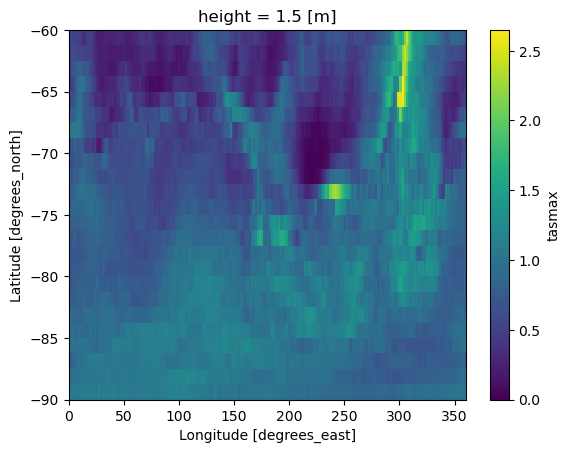

In [70]:
pr_epochs.isel(time=-1).plot()

# Percentiles - draft array

In [35]:
import numpy as np


def sorted_percentile(sorted_vals, percentile, n_valid=None):
    """Extract a percentile from a pre-sorted 1D array. O(1).

    Linear interpolation between order statistics, matching np.percentile's
    default (method='linear').

    sorted_vals: sorted ascending, NaNs at the end.
    percentile: in [0, 100].
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)
    if n_valid == 0:
        return np.nan

    # Fractional index into the valid block: 0 -> index 0, 100 -> n_valid-1.
    pos = (n_valid - 1) * percentile / 100.0
    below = int(np.floor(pos))
    above = min(below + 1, n_valid - 1)  # clip so 100 doesn't run past the end

    return sorted_vals[below] + (pos - below) * (
        sorted_vals[above] - sorted_vals[below]
    )

In [199]:
def exceedances(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

In [200]:
def threshold_exceedances_sorted(sorted_vals, threshold, n_valid=None):
    """Values strictly above a threshold, from pre-sorted data.

    sorted_vals: sorted ascending, NaNs at the end.
    threshold: exceedances are strictly greater than this.
    n_valid: number of non-NaN values. If None, uses the whole array.
    """
    if n_valid is None:
        n_valid = len(sorted_vals)

    # Binary search for first index above threshold. Slicing to n_valid
    # excludes NaNs, which sort as greater than everything.
    start = np.searchsorted(sorted_vals[:n_valid], threshold, side='right')
    return sorted_vals[start:n_valid]

# Probability Ratio

$PR = \dfrac{P_{hist}}{P_{hist nat}}$

In [201]:
q = 99

In [202]:
arr_sorted = np.sort(arr)
arr_nat_sorted = np.sort(arr_nat)

In [203]:
arr_counts = len(arr_sorted)

In [204]:
nat_q_float = sorted_percentile(arr_nat_sorted, q)
nat_q_float

np.float32(276.3362)

In [205]:
hist_q_exceedances = threshold_exceedances_sorted(arr_sorted, nat_q_float)

In [206]:
len(hist_q_exceedances)/len(arr_sorted)

0.005303030303030303

In [207]:
window = 30 * 365
window_counts = []
for i in range(len(arr_sorted)-window):
    sub_arr = arr[i:i+window]
    counts = np.count_nonzero(sub_arr > nat_q_float)
    window_counts.append(counts)

window_counts = np.array(window_counts)

In [208]:
p_hist = window_counts/window
p_hist

array([0.00255708, 0.00255708, 0.00255708, ..., 0.01214612, 0.01214612,
       0.01214612], shape=(48450,))

In [209]:
p_nat = (100 - q)/100

In [210]:
pr_arr = p_hist/p_nat

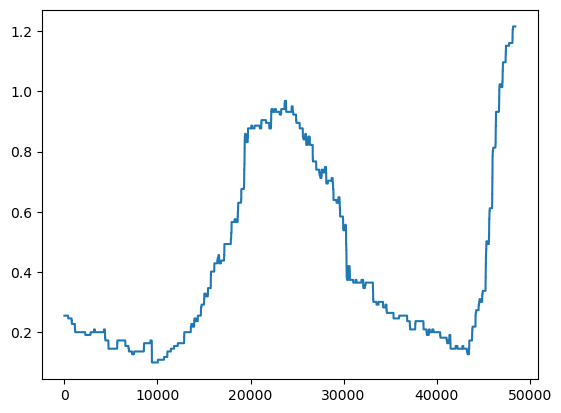

In [211]:
plt.plot(pr_arr)

In [212]:
len(pr_arr)

48450

In [236]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

Text(0.5, 0.96, "Probability ratio at {'lat': -62, 'lon': 57, 'method': 'nearest'}")

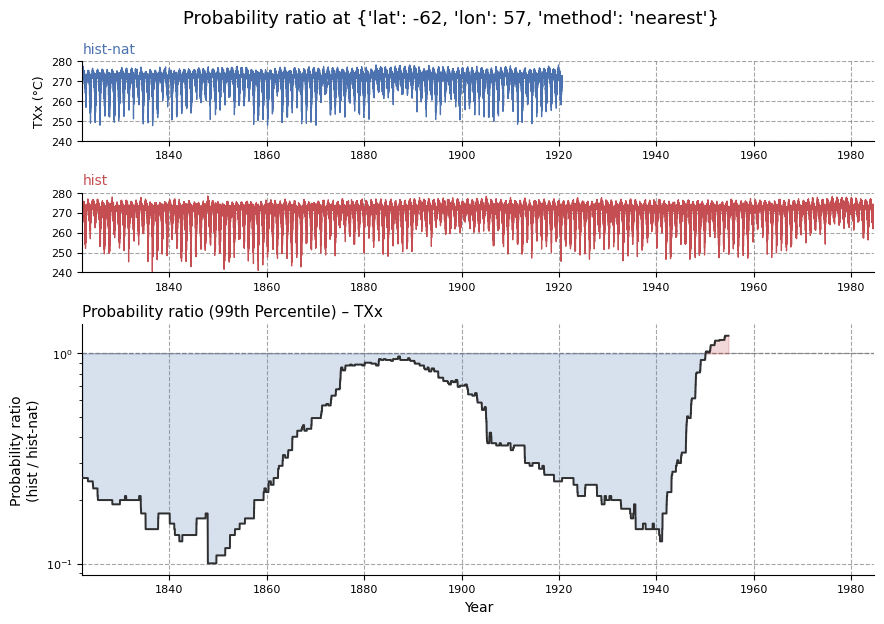

In [240]:


C_NAT, C_HIST, C_PR = "#4C72B0", "#C44E52", "#2F2F2F"

t = np.asarray(hist_time)
xlim = (t.min(), t.max())

fig = plt.figure(figsize=(9, 6.5))
gs = GridSpec(3, 1, figure=fig, height_ratios=[0.7, 0.7, 2.2],
              hspace=0.38, left=0.09, right=0.97, top=0.88, bottom=0.09)

ax_nat  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1])
ax_pr   = fig.add_subplot(gs[2])

ax_nat.plot(hist_nat_time, arr_nat, lw=0.9, color=C_NAT)
ax_nat.set_title("hist-nat", fontsize=10, loc="left", color=C_NAT)
ax_nat.set_ylabel("TXx (°C)", fontsize=9)

ax_hist.plot(hist_time, arr, lw=0.9, color=C_HIST)
ax_hist.set_title("hist", fontsize=10, loc="left", color=C_HIST)

ax_pr.axhline(1.0, color="0.55", lw=0.9, ls="--", zorder=1)
pr_time = hist_time[:len(pr_arr)]
ax_pr.plot(pr_time, pr_arr, lw=1.4, color=C_PR, zorder=3)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) >= 1.0,
                   color=C_HIST, alpha=0.22, interpolate=True, zorder=2)
ax_pr.fill_between(pr_time, 1.0, pr_arr, where=np.asarray(pr_arr) < 1.0,
                   color=C_NAT, alpha=0.22, interpolate=True, zorder=2)
ax_pr.set_yscale("log")
ax_pr.set_ylabel("Probability ratio\n(hist / hist-nat)", fontsize=10)
ax_pr.set_xlabel("Year", fontsize=10)
ax_pr.set_title(f"Probability ratio ({q}th Percentile) – TXx", fontsize=11, loc="left")

for ax in (ax_nat, ax_hist):
    ax.set_ylim(240, 280)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
for ax in (ax_nat, ax_hist, ax_pr):
    ax.set_xlim(xlim)
    ax.grid(True, linestyle='--', alpha=0.7, color='grey')
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    # if np.issubdtype(t.dtype, np.datetime64):
    ax.xaxis.set_major_locator(mdates.YearLocator(20))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        

fig.suptitle(f"Probability ratio at {loc}", fontsize=13, y=0.96)